In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%reload_ext autoreload

In [3]:
import pickle as pkl
import numpy as np
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *
from vae import *

In [3]:
#on runai
with open('/mydata/cope/mirco/data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/mydata/cope/mirco/data/ssp585_time_series.pkl'

In [4]:
#on local
with open('cope_data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

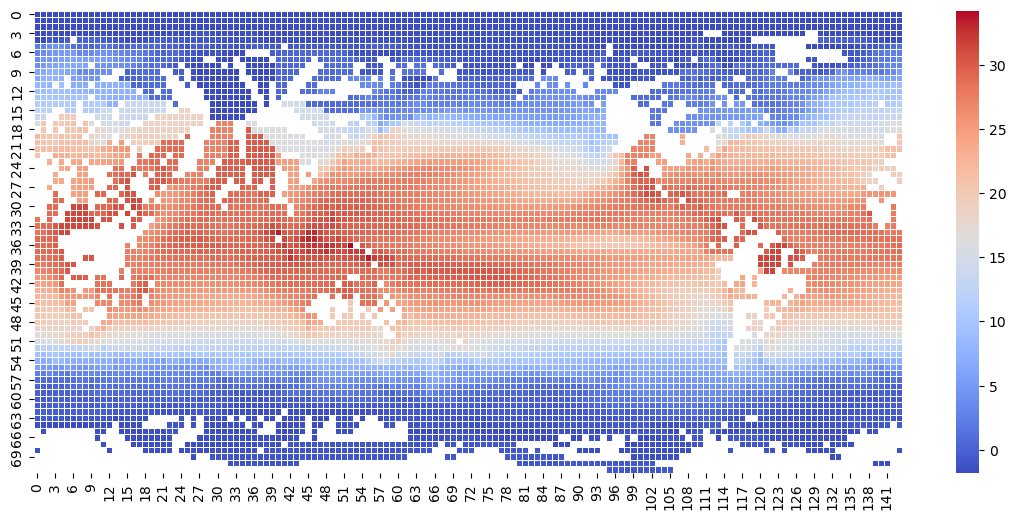

In [5]:
plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

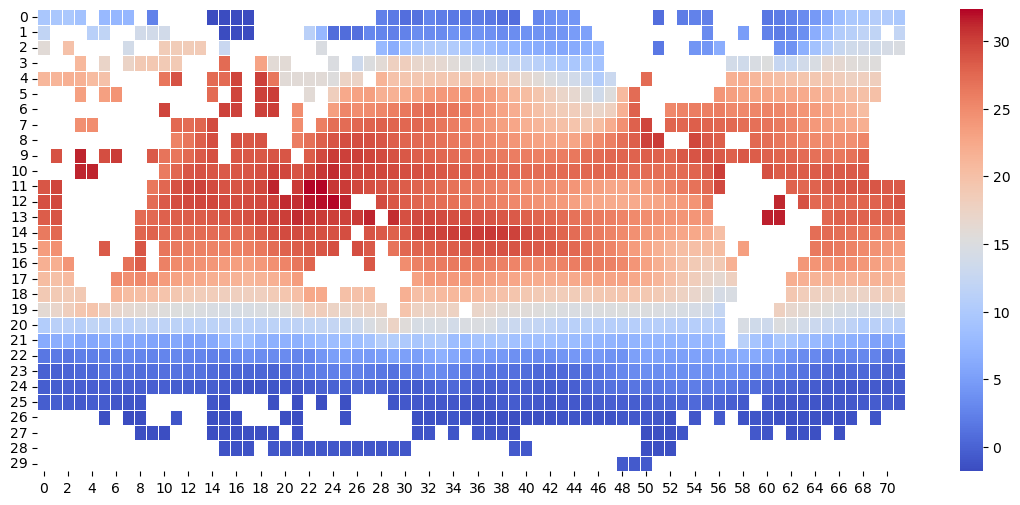

In [6]:
prune(cope_data, min_runs=5)
cut_lat(cope_data, max_lat=60)
downscale(cope_data)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

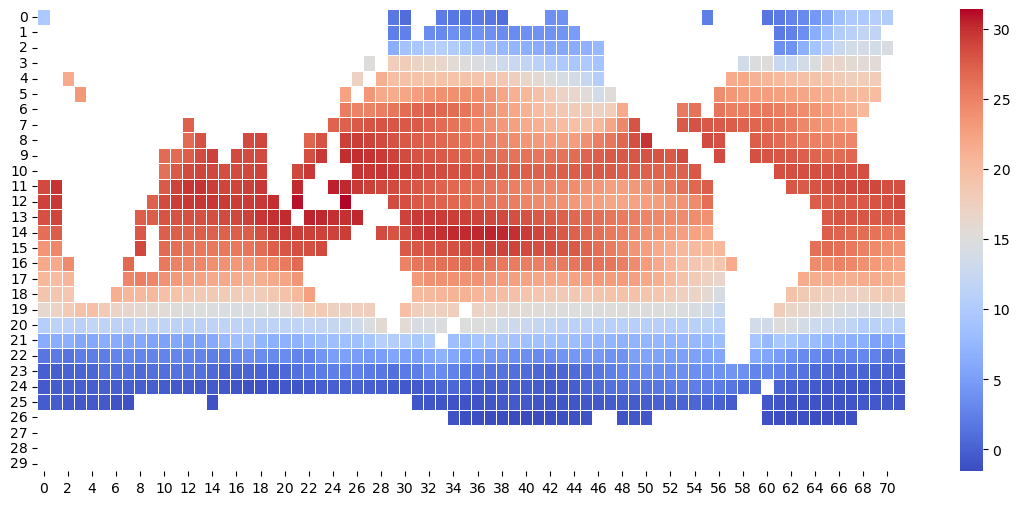

In [7]:
union_nan_mask = find_union_nan_mask(cope_data)
inpute(cope_data, union_nan_mask)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [8]:
X, Y = extract_images(cope_data, union_nan_mask, r=[-10, 10])
print(X.shape, Y.shape)

c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:58: RuntimeWarning: Mean of empty slice
  mean_timegrid = np.nanmean(runs_timegrids, axis=0)
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:59: RuntimeWarning: Mean of empty slice
  mean_grid = np.nanmean(mean_timegrid, axis=0)
c:\Users\mirco\anaconda3\envs\research_project\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:62: RuntimeWarning: Mean of empty slice
  std_grid = np.nanmean(std_timegrid, axis=0)
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:67: RuntimeWarning: Mean of empty slice
  mean_forced_responses = np.nanmean(runs_timegrids_normalized, axis=0)


(612, 34, 30, 72) (612, 34, 30, 72)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [10]:
batch_size = 16

cope_dataset = CopeDataset(samples=X, labels=Y)

train_dataset, test_dataset = random_split(cope_dataset, [0.8, 0.2])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [13]:
lr = 2e-3
epochs = 10

model = CVAE(mask=union_nan_mask, in_channels=34, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("Start training CVAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

input shape : torch.Size([34, 30, 72])
encoded shape : torch.Size([136, 30, 72])
flattened encoded : 293760
Start training CVAE...
Epoch 1 complete ! 	Average Loss:  1973573.5720052083
Epoch 2 complete ! 	Average Loss:  70296.08401692708
Epoch 3 complete ! 	Average Loss:  18409.345068359376
Epoch 4 complete ! 	Average Loss:  8554.62491048177
Epoch 5 complete ! 	Average Loss:  5742.989689127604
Epoch 6 complete ! 	Average Loss:  5035.87939453125
Epoch 7 complete ! 	Average Loss:  4440.818876139323
Epoch 8 complete ! 	Average Loss:  3734.962508138021
Epoch 9 complete ! 	Average Loss:  3921.4882649739584
Epoch 10 complete ! 	Average Loss:  7722.612866210938
Finish!!


In [12]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)
        x_hat.detach()

        break

In [13]:
print(x.shape)
print(x_hat.shape)
print(y.shape)

torch.Size([16, 34, 30, 72])
torch.Size([16, 34, 30, 72])
torch.Size([16, 34, 30, 72])


In [14]:
x, x_hat, y = x.numpy(), x_hat.numpy(), y.numpy()

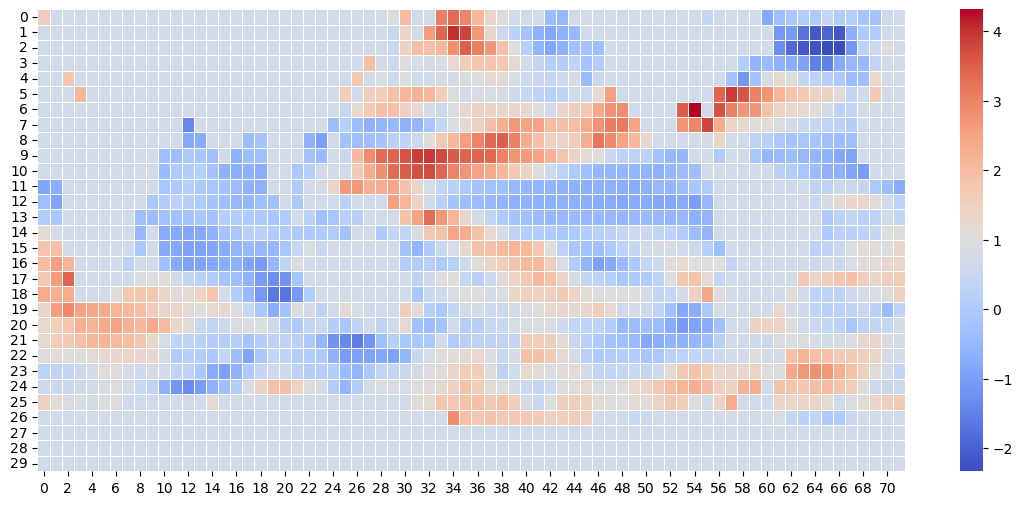

In [26]:
plot_grid(x[0][33])

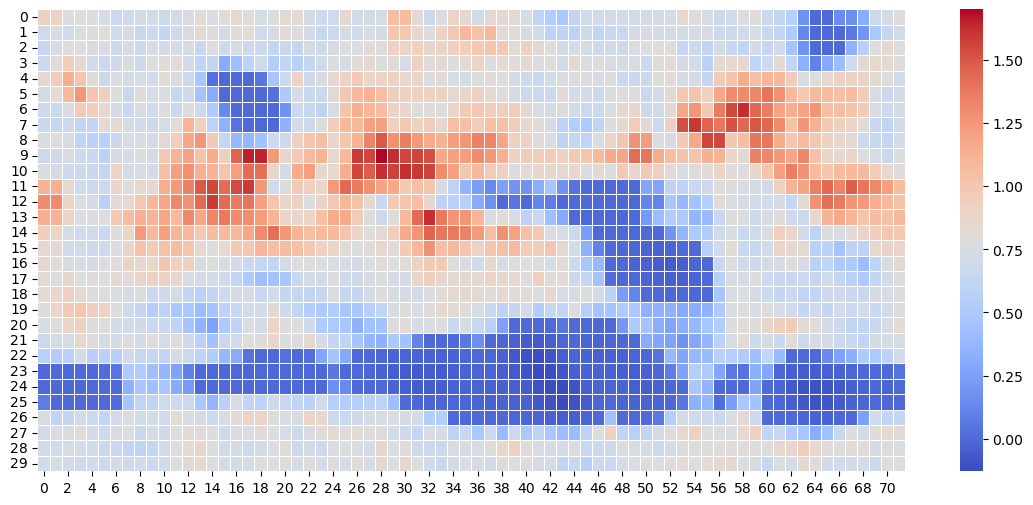

In [23]:
plot_grid(x_hat[0][33])

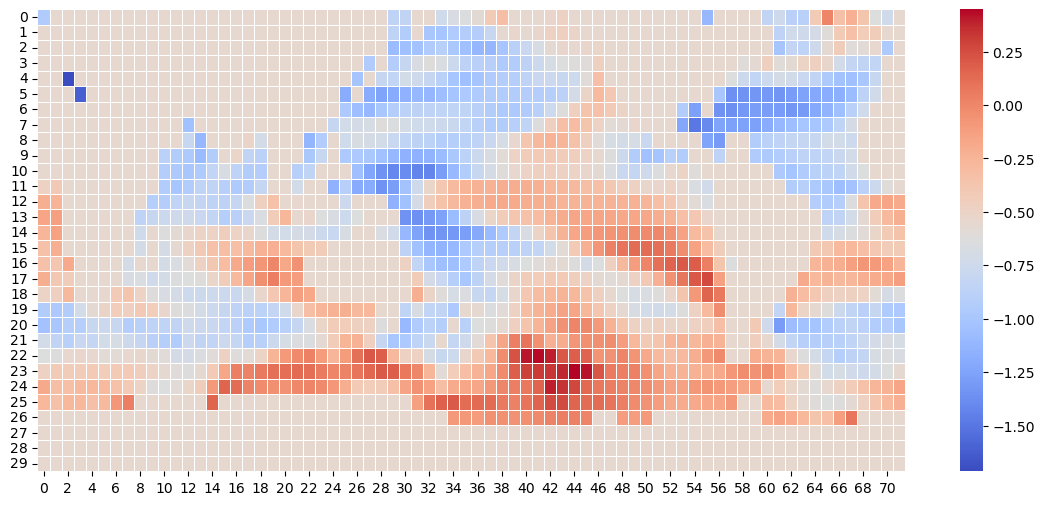

In [117]:
plot_grid(y[0][0])

5.265011 -4.6404276


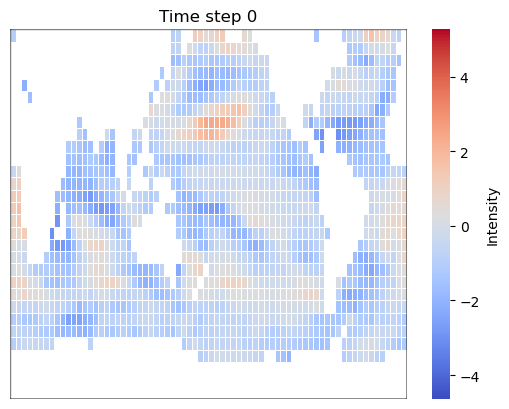

In [15]:
from plots import get_animated_timeserie

a = get_animated_timeserie(x[0], union_nan_mask)
a.save('x.gif', writer='pillow', fps=1)

C:\Users\mirco\AppData\Local\Temp\ipykernel_10744\1817344449.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = get_animated_timeserie(np.array(x_hat[0]), union_nan_mask)


2.3774114 -2.0995712


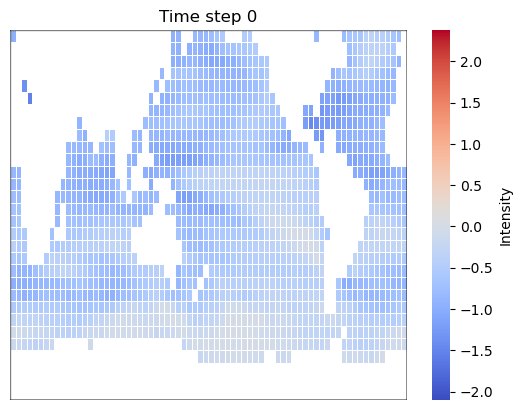

In [37]:
from plots import get_animated_timeserie

a = get_animated_timeserie(x_hat[0], union_nan_mask)
a.save('x_hat.gif', writer='pillow', fps=1)

C:\Users\mirco\AppData\Local\Temp\ipykernel_10744\3833773037.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = get_animated_timeserie(np.array(y[0]), union_nan_mask)


2.6262555 -2.6271024


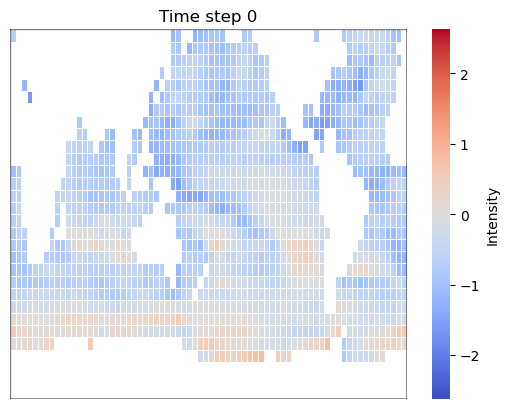

In [38]:
from plots import get_animated_timeserie

a = get_animated_timeserie(y[0], union_nan_mask)
a.save('y.gif', writer='pillow', fps=1)

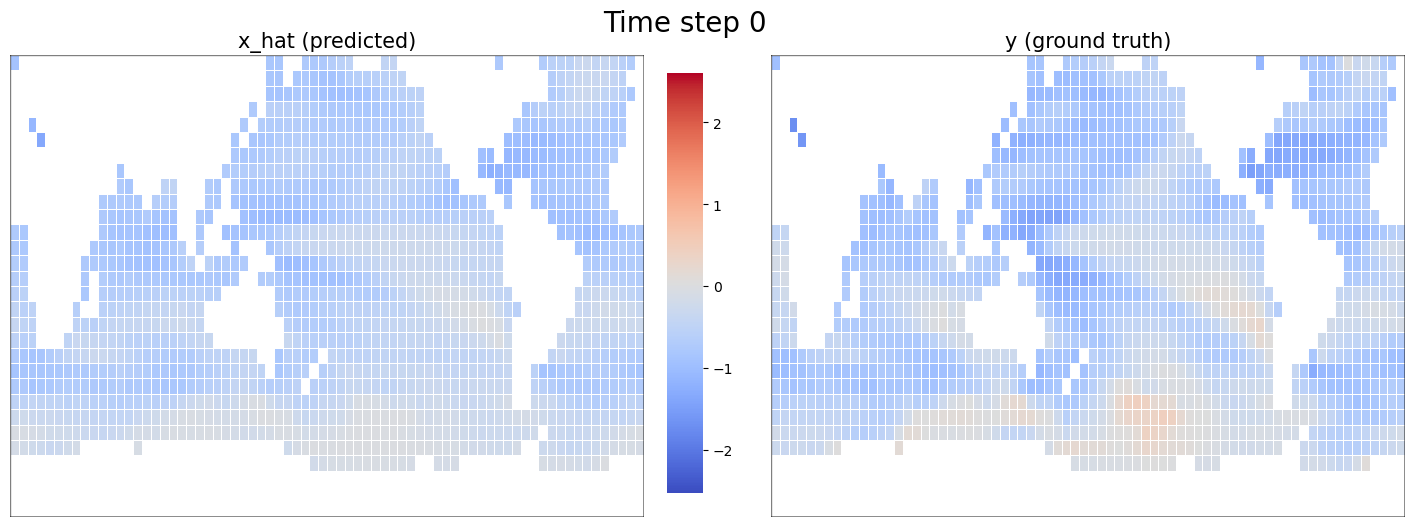

In [17]:
from plots import get_duo_animated_timeserie

a = get_duo_animated_timeserie(x_hat[0], y[0], union_nan_mask)
a.save('compare_pred_and_truth2.gif', writer='pillow', fps=1)

In [19]:
import os
os.environ['PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT']='2'

In [ ]:
"""
TODO :
1)  Créer un LOOCV pour le VAE (en utilisant le même principe que le ridge) - DONE
2)  Jouer un peu avec les paramtètres du VAE (lr, etc...) -> voir quand tu fais du sampling des variables latent, quelle est la tête des timeseries -> créer une animation (matplotlib animation FuncAnimation) - DONE
3)  Faire un CVAE en convulant en espace, pas en temps !
    (utiliser ltsm ou réduire size input à l'avance avec des techniques de réduction de dim -> comment extraire une map de input qui explique le plus le mfr y -> en convulant en espace ?)
4)  Pouvoir faire un confidence interval en samplant par ex. 10 images avec le decoder pour voir la performance du modèle
    Obtenir le mean et le logvar depuis le encoder, sample plusieurs z (page 13, équation 1.22) pour ensuite faire un confidence interval.
5)  Faire un script sans standardization (juste centrer en temps les données)
6)  Investiguer le timeVAE
"""

In [ ]:
"""
1) Extract principal components from the the weight matrix 

(on pourrait dire que reduire le rank on ne perd pas bcp d'accuracy)
"""

In [ ]:
# Specify parameters
epochs = 1
batch_size = 16
lr = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

model = VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

ith = 1

print('Begin cross validation...\n')

mse_losses, nmse_losses = VAE_LOOCV(cope_data, union_nan_mask, model, epochs, batch_size, lr, verbose=True)

print(f'Finished !')

ith += 1

print('\nFinished training !\n')

Using device: cpu
Begin cross validation...

Epoch 1 complete ! 	Average training loss:  10413.172678392986
[1/29] For eval model ICON-ESM-LR, 	 MSE is 8194.85, 	 NMSE is 131392.61
Epoch 1 complete ! 	Average training loss:  5664.426332019624
[2/29] For eval model EC-Earth3, 	 MSE is 7678.19, 	 NMSE is 266390.03
Epoch 1 complete ! 	Average training loss:  4556.8239339192705
[3/29] For eval model CMCC-CM2-SR5, 	 MSE is 9406.98, 	 NMSE is 163113.19


KeyboardInterrupt: 

In [23]:
n_samples = 5

model.eval()
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        samples = model.sample(x, n_samples)

        break

In [25]:
len(samples)

5

In [24]:
samples[0].shape

torch.Size([44472])